##**HEART ATTACK RISK CLASSIFICATION**

## **Problem Statement**
The goal of this project is to develop a **classification model** that can predict the likelihood of a **heart attack** based on various **patient health indicators**. The dataset contains information on patients' demographic details, medical history, and diagnostic measures. The primary objective is to accurately classify patients into two categories: those with a higher likelihood of experiencing a heart attack (**target = 1**) and those with a lower likelihood (**target = 0**).

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## **Understanding Variables**
**Age** – Age of the patient in years.

**Sex** – Gender of the patient (M = Male, F = Female).

**ChestPainType** – Type of chest pain experienced by the patient.

**RestingBP** – Blood pressure level when the patient is at rest.

**Cholesterol** – Cholesterol level in the patient’s blood.

**FastingBS** – Whether fasting blood sugar is high (1 = Yes, 0 = No).

**RestingECG** – Result of the resting electrocardiogram test.

**MaxHR** – Maximum heart rate achieved during exercise.

**ExerciseAngina** – Whether chest pain occurs during exercise (Y = Yes, N = No).

**Oldpeak** – ST depression value measured during exercise (heart stress indicator).

**ST_Slope** – Slope pattern of the ST segment during peak exercise.

**HeartDisease** – Whether the patient has heart disease (1 = Yes, 0 = No).

**Load data**

In [2]:
data= pd.read_csv('heart.csv')
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


**Basic checks**

In [3]:
# shape
data.shape

(918, 12)

In [4]:
# head
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
# tail
data.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [6]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
# dtypes
data.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [8]:
# columns
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
# num_cols
num_cols = data.select_dtypes(include=['float64','int64'])
num_cols

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [10]:
# num_cols
num_cols = data.select_dtypes(include=['float64','int64'])
num_cols

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289,0,172,0.0,0
1,49,160,180,0,156,1.0,1
2,37,130,283,0,98,0.0,0
3,48,138,214,0,108,1.5,1
4,54,150,195,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1
914,68,144,193,1,141,3.4,1
915,57,130,131,0,115,1.2,1
916,57,130,236,0,174,0.0,1


In [11]:
# cat_cols
cat_cols = data.select_dtypes(include=['object'])
cat_cols

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [12]:
# describe
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
# unique
for x in cat_cols:
  print(x,'-->',data[x].unique())

Sex --> ['M' 'F']
ChestPainType --> ['ATA' 'NAP' 'ASY' 'TA']
RestingECG --> ['Normal' 'ST' 'LVH']
ExerciseAngina --> ['N' 'Y']
ST_Slope --> ['Up' 'Flat' 'Down']


In [14]:
# value counts
for x in cat_cols:
  print(data[x].value_counts())

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


# **Data Cleaning**

In [15]:
# check for missing values
data.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [16]:
# check for duplicates
data.duplicated().sum()

np.int64(0)

###**Exloratory data analysis**

**Univariate**

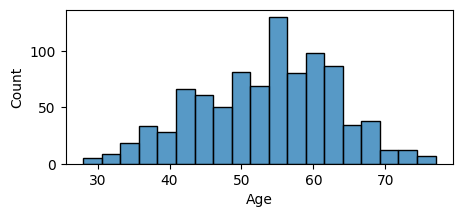

In [17]:
# check the distribution of Age
plt.figure(figsize=(5,2))
sns.histplot(data,x='Age')
plt.show()

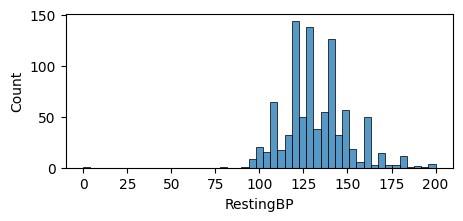

In [18]:
# check the distribution of 	RestingBP
plt.figure(figsize=(5,2))
sns.histplot(data,x='RestingBP')
plt.show()

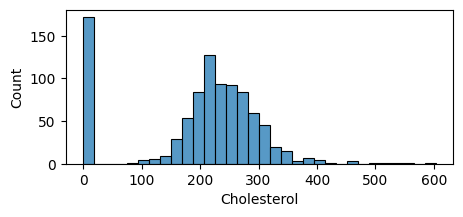

In [19]:
# check the distribution of 	Cholesterol
plt.figure(figsize=(5,2))
sns.histplot(data,x='Cholesterol')
plt.show()

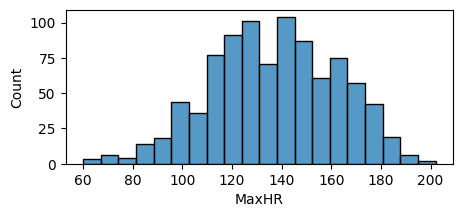

In [20]:
# check the distribution of 	MaxHR
plt.figure(figsize=(5,2))
sns.histplot(data,x='MaxHR')
plt.show()

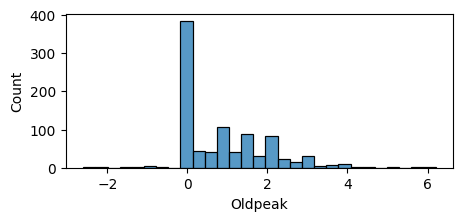

In [21]:
# check the distribution of 	Oldpeak
plt.figure(figsize=(5,2))
sns.histplot(data,x='Oldpeak')
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

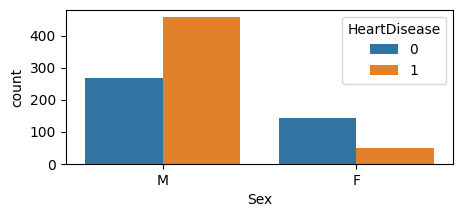

In [22]:
# count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='Sex',hue='HeartDisease')

<Axes: xlabel='ChestPainType', ylabel='count'>

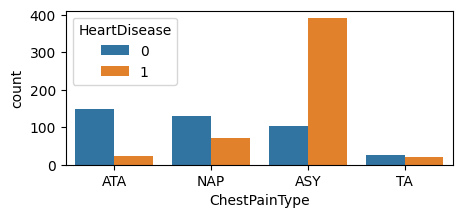

In [23]:
# count of ChestPainType
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType',hue='HeartDisease')

<Axes: xlabel='RestingECG', ylabel='count'>

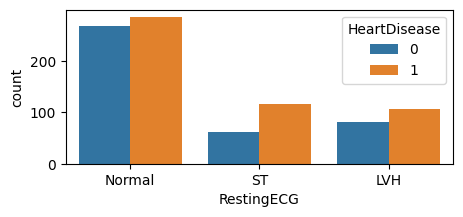

In [24]:
# count of RestingECG
plt.figure(figsize=(5,2))
sns.countplot(data,x='RestingECG',hue='HeartDisease')

<Axes: xlabel='ExerciseAngina', ylabel='count'>

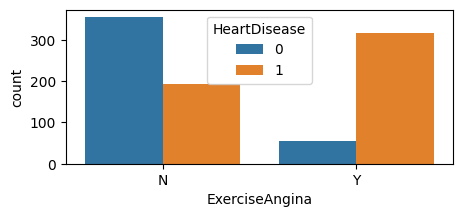

In [25]:
# count of ExerciseAngina
plt.figure(figsize=(5,2))
sns.countplot(data,x='ExerciseAngina',hue='HeartDisease')

<Axes: xlabel='ST_Slope', ylabel='count'>

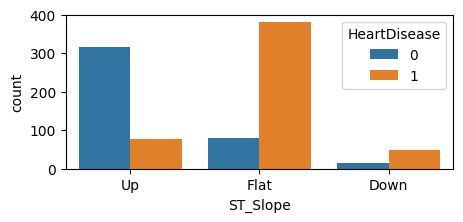

In [26]:
# ST_Slope
plt.figure(figsize=(5,2))
sns.countplot(data,x='ST_Slope',hue='HeartDisease')

# Bivariate Analysis

<Axes: xlabel='Age', ylabel='Cholesterol'>

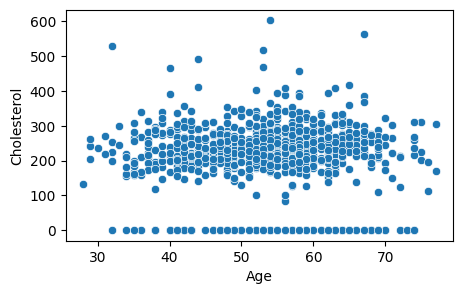

In [27]:
# age v/s Cholesterol
plt.figure(figsize=(5,3))
sns.scatterplot(data,x='Age',y='Cholesterol')

<Axes: xlabel='Age', ylabel='RestingBP'>

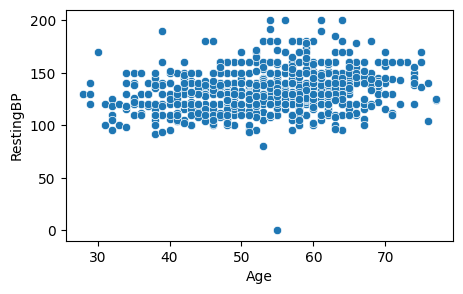

In [28]:
# age v/s RestingBP
plt.figure(figsize=(5,3))
sns.scatterplot(data,x='Age',y='RestingBP')

<Axes: xlabel='Age', ylabel='MaxHR'>

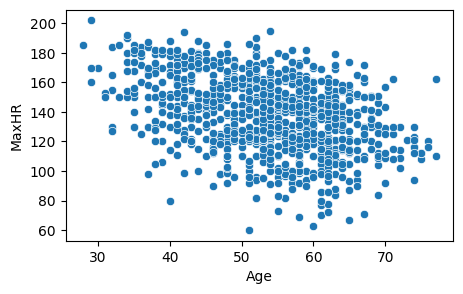

In [29]:
# age v/s MaxHR
plt.figure(figsize=(5,3))
sns.scatterplot(data,x='Age',y='MaxHR')

**Pairplot**

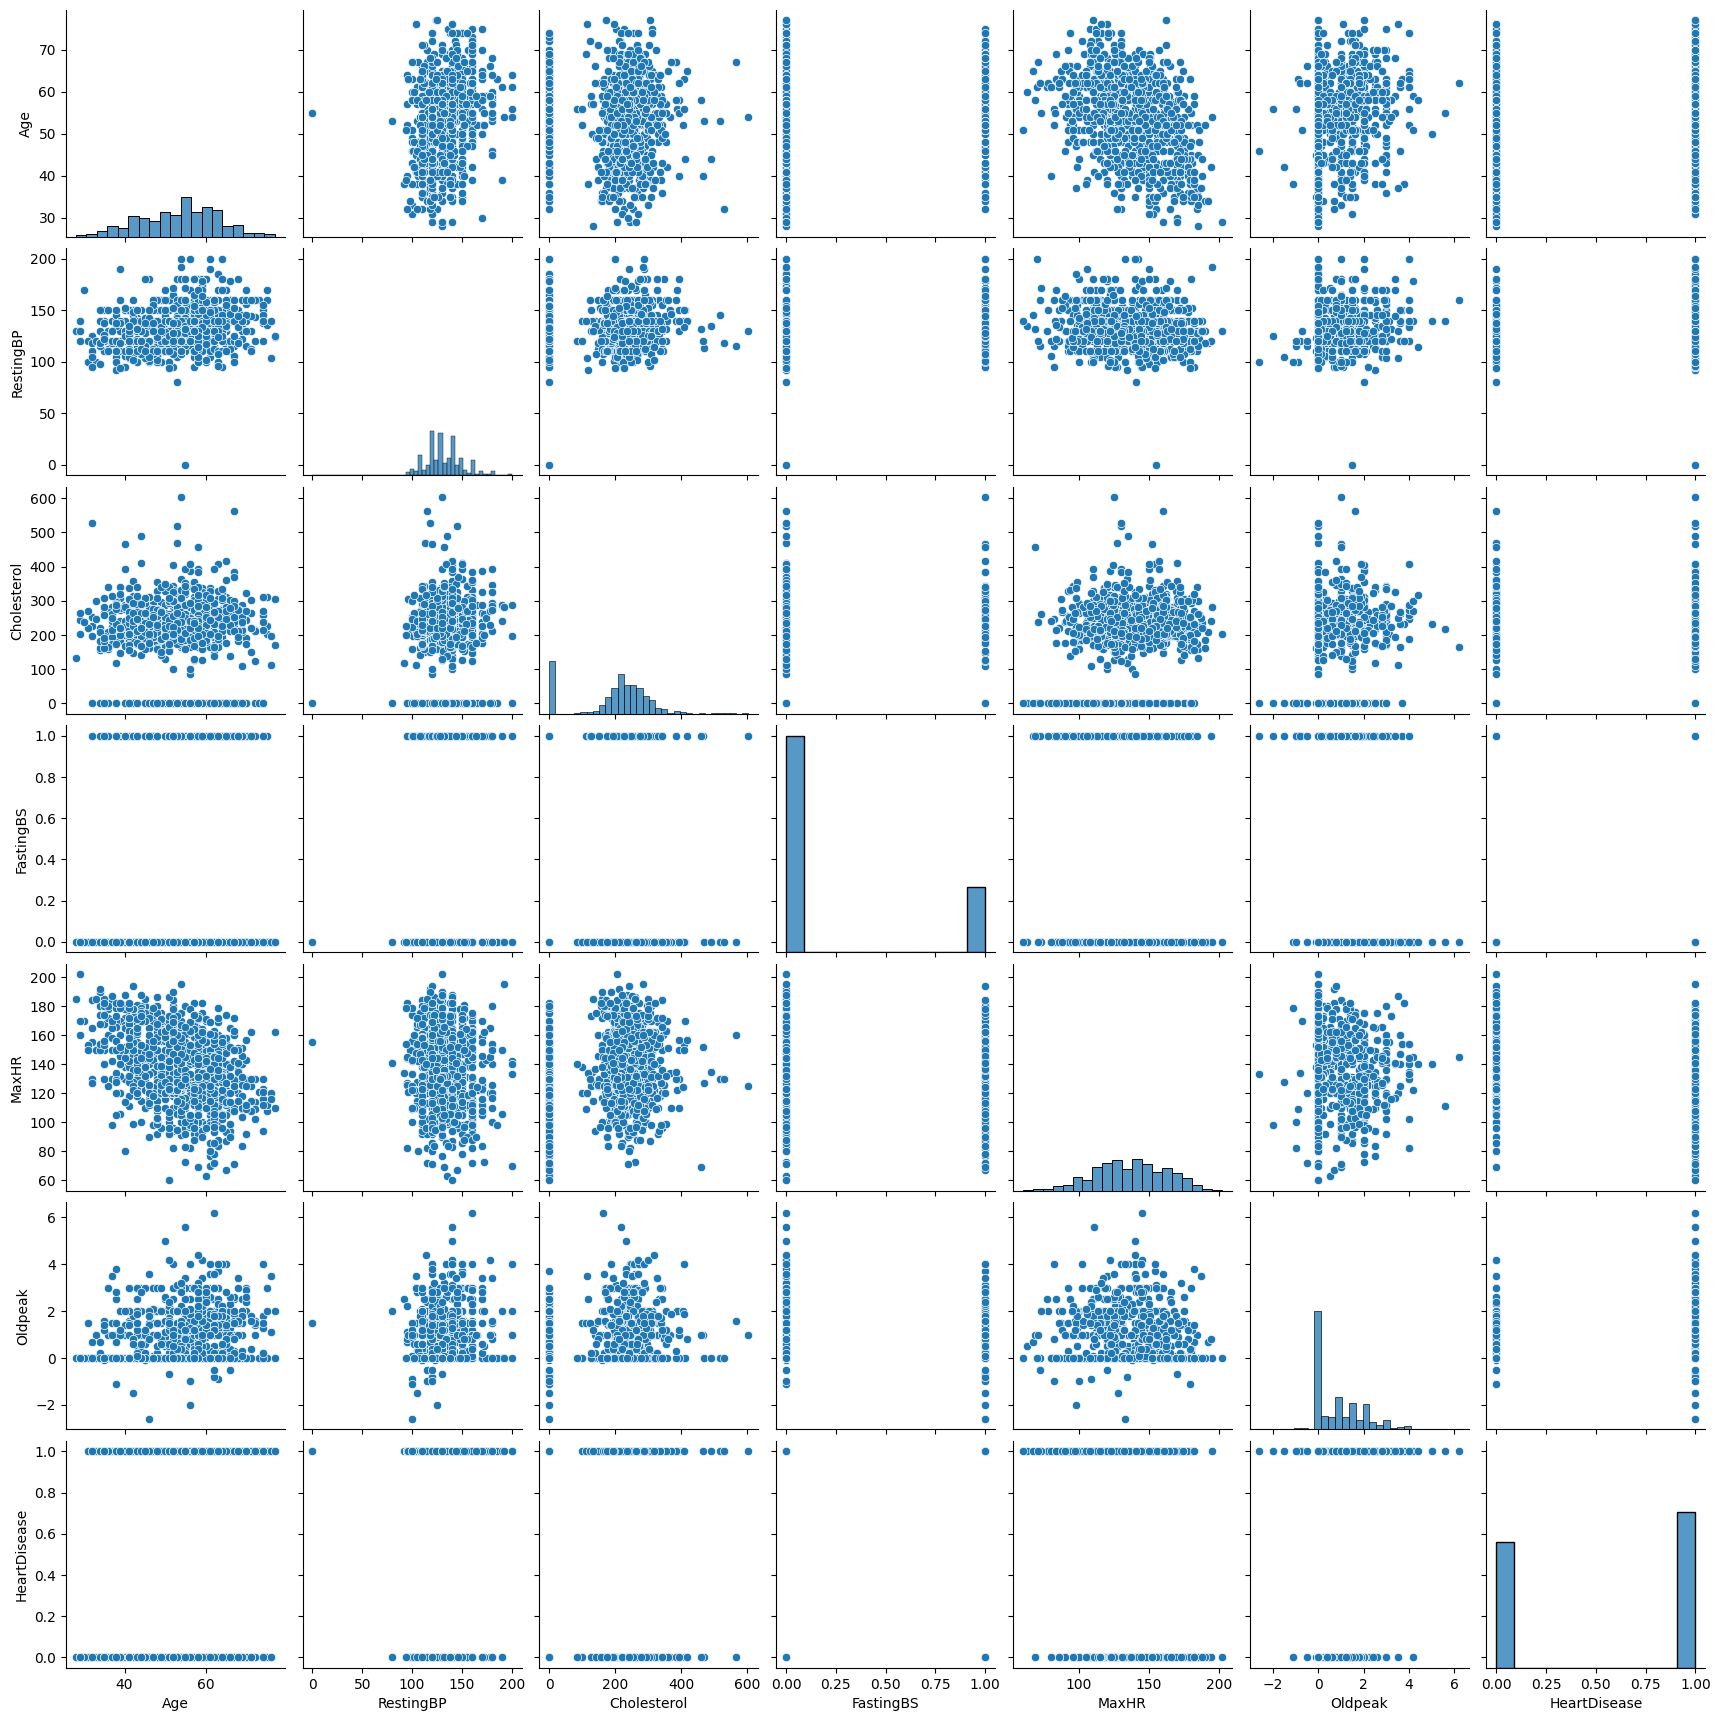

In [30]:
sns.pairplot(data)

**Heat Map**

In [31]:
num_cols.corr()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


<Axes: >

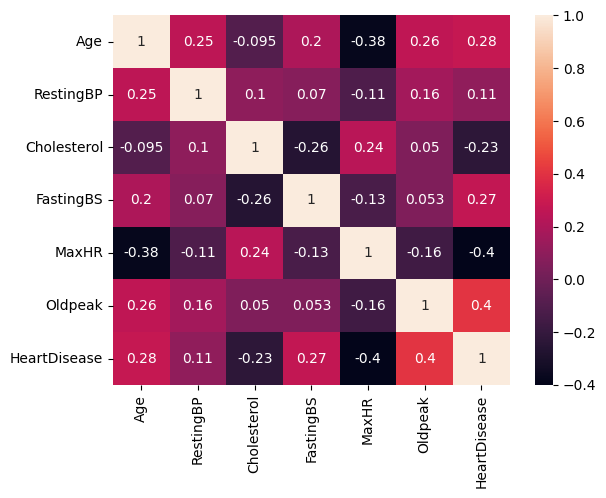

In [32]:
sns.heatmap(num_cols.corr(),annot=True)

**Handle Outliers**

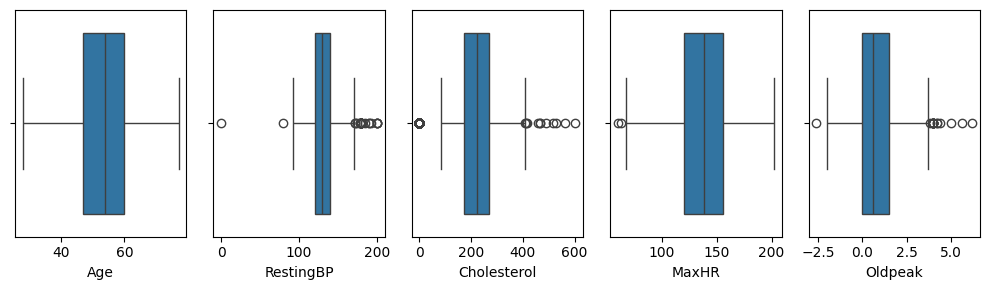

In [33]:
# check outliers
fig,ax = plt.subplots(1,5 , figsize=(10,3))
sns.boxplot(data,x='Age',ax=ax[0])
sns.boxplot(data,x='RestingBP',ax=ax[1])
sns.boxplot(data,x='Cholesterol',ax=ax[2])
sns.boxplot(data,x='MaxHR',ax=ax[3])
sns.boxplot(data,x='Oldpeak',ax=ax[4])
plt.tight_layout()




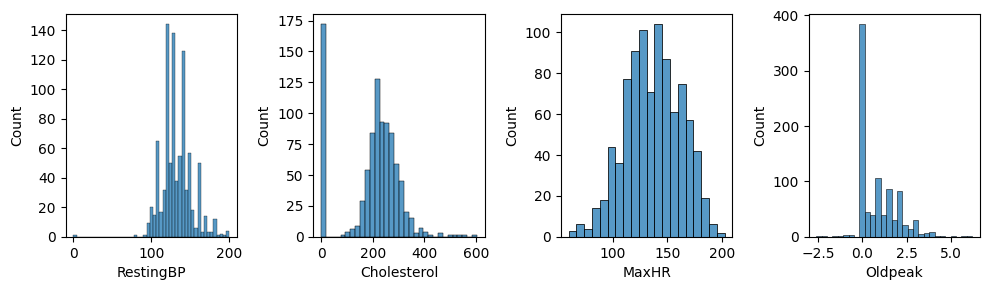

In [34]:
# check the distribution
fig,ax = plt.subplots(1,4 , figsize=(10,3))
sns.histplot(data,x='RestingBP',ax=ax[0])
sns.histplot(data,x='Cholesterol',ax=ax[1])
sns.histplot(data,x='MaxHR',ax=ax[2])
sns.histplot(data,x='Oldpeak',ax=ax[3])
plt.tight_layout()

In [35]:
A =['RestingBP','Cholesterol','MaxHR','Oldpeak']
for x in A:
  print(x,'-->',data[x].skew())

RestingBP --> 0.1798393100516288
Cholesterol --> -0.6100864307268192
MaxHR --> -0.14435941846180994
Oldpeak --> 1.0228720218107528


- RestingBP , MaxHR distribution is normal as its skewness is between [-0.5,0.5]
- Cholesterol and Oldpeak is skewed

**Cholesterol**

In [36]:
# IQR
Q1 = data.loc[:,'Cholesterol'].quantile(0.25)
Q3 = data.loc[:,'Cholesterol'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3 + 1.5 *IQR


In [37]:
data[(data.loc[:,'Cholesterol']>upper_limit) | (data.loc[:,'Cholesterol']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1
536,62,M,NAP,133,0,1,ST,119,Y,1.2,Flat,1
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
667,65,F,NAP,140,417,1,LVH,157,N,0.8,Up,0


In [38]:
len(data[(data.loc[:,'Cholesterol']>upper_limit) | (data.loc[:,'Cholesterol']<lower_limit)])/len(data)*100

19.934640522875817

**Oldpeak**

In [39]:
Q1 = data.loc[:,'Oldpeak'].quantile(0.25)
Q3 = data.loc[:,'Oldpeak'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3 + 1.5 *IQR

In [40]:
data[(data.loc[:,'Oldpeak']>upper_limit) | (data.loc[:,'Oldpeak']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
68,52,M,ASY,160,246,0,ST,82,Y,4.0,Flat,1
166,50,M,ASY,140,231,0,ST,140,Y,5.0,Flat,1
324,46,M,ASY,100,0,1,ST,133,N,-2.6,Flat,1
500,65,M,ASY,136,248,0,Normal,140,Y,4.0,Down,1
521,61,M,ASY,120,282,0,ST,135,Y,4.0,Down,1
537,74,M,ASY,150,258,1,ST,130,Y,4.0,Down,1
559,64,M,ASY,134,273,0,Normal,102,Y,4.0,Down,1
624,63,F,ASY,150,407,0,LVH,154,N,4.0,Flat,1
702,59,M,TA,178,270,0,LVH,145,N,4.2,Down,0
732,56,F,ASY,200,288,1,LVH,133,Y,4.0,Down,1


In [41]:
len(data[(data.loc[:,'Oldpeak']>upper_limit) | (data.loc[:,'Oldpeak']<lower_limit)])/len(data)*100

1.7429193899782136

In [42]:
data.loc[(data.loc[:,'Oldpeak']>upper_limit) |
 (data.loc[:,'Oldpeak']<lower_limit),'Oldpeak']=data.loc[:,'Oldpeak'].median()

**RestingBP**

In [43]:
data[(data.loc[:,'RestingBP']>upper_limit)|(data.loc[:,'RestingBP']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [44]:
data.loc[(data.loc[:,'RestingBP']>upper_limit)|
 (data.loc[:,'RestingBP']<lower_limit),'RestingBP']=data.loc[:,'RestingBP'].mean()

/tmp/ipykernel_378/734573612.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.39651416122004' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'RestingBP']>upper_limit)|


**MaxHR**

In [45]:
mean_val = data.loc[:,'MaxHR'].mean()
std_val =data.loc[:,'MaxHR'].std()
lower_limit= mean_val - 3* std_val
upper_limit= mean_val + 3*std_val

In [46]:
data[(data.loc[:,'MaxHR']>upper_limit)|(data.loc[:,'MaxHR']<lower_limit)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
390,51,M,ASY,132.396514,0,0,Normal,60,N,0.0,Flat,1


In [47]:
data.loc[(data.loc[:,'MaxHR']>upper_limit)|
 (data.loc[:,'MaxHR']<lower_limit),'MaxHR']=data.loc[:,'MaxHR'].mean()

/tmp/ipykernel_378/3454964119.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.80936819172112' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data.loc[:,'MaxHR']>upper_limit)|


# Encoding

In [48]:
# ExerciseAngina: Y or N
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Exercise_Angina'] = le.fit_transform(data.loc[:,'ExerciseAngina'])

In [49]:
# Sex: Male and Female
data = pd.get_dummies(data,columns=['Sex'],dtype='int')
data

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Exercise_Angina,Sex_F,Sex_M
0,40,ATA,132.396514,289,0,Normal,172.0,N,0.0,Up,0,0,0,1
1,49,NAP,132.396514,180,0,Normal,156.0,N,1.0,Flat,1,0,1,0
2,37,ATA,132.396514,283,0,ST,98.0,N,0.0,Up,0,0,0,1
3,48,ASY,132.396514,214,0,Normal,108.0,Y,1.5,Flat,1,1,1,0
4,54,NAP,132.396514,195,0,Normal,122.0,N,0.0,Up,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,TA,132.396514,264,0,Normal,132.0,N,1.2,Flat,1,0,0,1
914,68,ASY,132.396514,193,1,Normal,141.0,N,3.4,Flat,1,0,0,1
915,57,ASY,132.396514,131,0,Normal,115.0,Y,1.2,Flat,1,1,0,1
916,57,ATA,132.396514,236,0,LVH,174.0,N,0.0,Flat,1,0,1,0


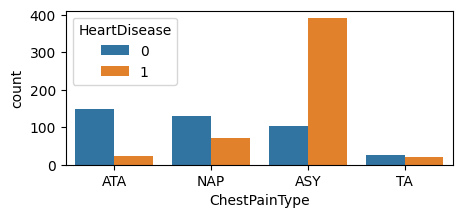

In [50]:
# ChestPainType	 comapre with HeartDisease
plt.figure(figsize=(5,2))
sns.countplot(data,x='ChestPainType',hue='HeartDisease')
plt.show()

In [51]:
data.loc[:,'Chest_PainType']= data.loc[:,'ChestPainType'].map({'TA':0,'ATA':1,'NAP':2,'ASY':3})

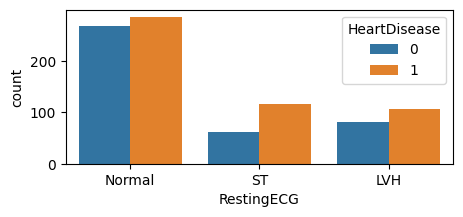

In [52]:
# RestingECG
plt.figure(figsize=(5,2))
sns.countplot(data,x='RestingECG',hue='HeartDisease')
plt.show()

In [53]:
data.loc[:,'Resting_ECG']= data.loc[:,'RestingECG'].map({'Normal':0,'ST':1,'LVH':2})

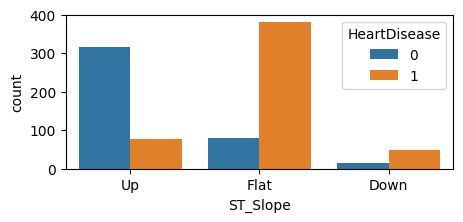

In [54]:
# ST_Slope
plt.figure(figsize=(5,2))
sns.countplot(data,x='ST_Slope',hue='HeartDisease')
plt.show()

In [55]:
data.loc[:,'st_Slope']=data.loc[:,'ST_Slope'].map({'Down':0,'Up':1,'Flat':2})

In [56]:
data.drop(columns=['ChestPainType','RestingECG','ExerciseAngina','ST_Slope'],inplace=True)

# Scaling

In [57]:
# standard Scaler
# Age,RestingBP	,Cholesterol,MaxHR
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
data[['Age']]= sc.fit_transform(data[['Age']])
data[['RestingBP']]= sc.fit_transform(data[['RestingBP']])
data[['Cholesterol']]= sc.fit_transform(data[['Cholesterol']])
data[['MaxHR']]= sc.fit_transform(data[['MaxHR']])

# Feature Engineering

In [58]:
# All features are important
data

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Exercise_Angina,Sex_F,Sex_M,Chest_PainType,Resting_ECG,st_Slope
0,-1.433140,0.033023,0.825070,0,1.386546,0.0,0,0,0,1,1,0,1
1,-0.478484,0.033023,-0.171961,0,0.754627,1.0,1,0,1,0,2,0,2
2,-1.751359,0.033023,0.770188,0,-1.536076,0.0,0,0,0,1,1,1,1
3,-0.584556,0.033023,0.139040,0,-1.141127,1.5,1,1,1,0,3,0,2
4,0.051881,0.033023,-0.034755,0,-0.588199,0.0,0,0,0,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,0.033023,0.596393,0,-0.193250,1.2,1,0,0,1,0,0,2
914,1.536902,0.033023,-0.053049,1,0.162204,3.4,1,0,0,1,3,0,2
915,0.370100,0.033023,-0.620168,0,-0.864663,1.2,1,1,0,1,3,0,2
916,0.370100,0.033023,0.340275,0,1.465535,0.0,1,0,1,0,1,2,2


# Split data for x and y

In [59]:
x = data.drop(columns='HeartDisease')
y= data.loc[:,'HeartDisease']

# Split data for Training and Testing

In [60]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# How to Balance Data

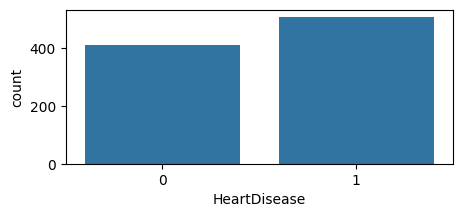

In [61]:
# check data is balanced or not
plt.figure(figsize=(5,2))
sns.countplot(data,x='HeartDisease')
plt.show()

In [62]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)


In [63]:
Counter(y)

Counter({0: 410, 1: 508})

In [64]:
Counter(y_sampled)

Counter({0: 401, 1: 401})

# Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [66]:
# slope
model.coef_

array([[ 0.18527873, -0.13705858, -0.43544734,  1.03072307, -0.26036119,
         0.64466214,  1.29273699, -0.54454387,  0.54493923,  0.61785257,
         0.13015627,  1.18394424]])

In [67]:
# intercept
model.intercept_

array([-4.45457949])

In [68]:
model.predict_proba(x_test)

array([[0.96872652, 0.03127348],
       [0.82070487, 0.17929513],
       [0.03190626, 0.96809374],
       [0.02934392, 0.97065608],
       [0.93924168, 0.06075832],
       [0.22379016, 0.77620984],
       [0.23794574, 0.76205426],
       [0.71340198, 0.28659802],
       [0.5143102 , 0.4856898 ],
       [0.16014326, 0.83985674],
       [0.56150245, 0.43849755],
       [0.65214483, 0.34785517],
       [0.38903495, 0.61096505],
       [0.89269727, 0.10730273],
       [0.11057778, 0.88942222],
       [0.20926872, 0.79073128],
       [0.9348541 , 0.0651459 ],
       [0.54538719, 0.45461281],
       [0.33552905, 0.66447095],
       [0.82279619, 0.17720381],
       [0.5266585 , 0.4733415 ],
       [0.26787195, 0.73212805],
       [0.91660172, 0.08339828],
       [0.20141326, 0.79858674],
       [0.39774987, 0.60225013],
       [0.1292187 , 0.8707813 ],
       [0.93353496, 0.06646504],
       [0.2002728 , 0.7997272 ],
       [0.93369995, 0.06630005],
       [0.95786711, 0.04213289],
       [0.

In [69]:
y_pred

array([0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1])

# Evaluation of Classification
* Confusion Matrix
* Accuracy
* recall
* precision
* f1 score
* AUC-ROC curve

In [70]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score , roc_auc_score

In [71]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[69,  8],
       [21, 86]])

In [72]:
# accuracy
accuracy_score(y_test,y_pred)

0.842391304347826

In [73]:
# recall
recall_score(y_test,y_pred)

0.8037383177570093

In [74]:
# precision score
precision_score(y_test,y_pred)

0.9148936170212766

In [75]:
# f1 score
f1_score(y_test,y_pred)

0.8557213930348259

In [76]:
# auc -roc
from sklearn.metrics import roc_curve , roc_auc_score

In [77]:
y_prob = model.predict_proba(x_test)[:,1]
y_prob

array([0.03127348, 0.17929513, 0.96809374, 0.97065608, 0.06075832,
       0.77620984, 0.76205426, 0.28659802, 0.4856898 , 0.83985674,
       0.43849755, 0.34785517, 0.61096505, 0.10730273, 0.88942222,
       0.79073128, 0.0651459 , 0.45461281, 0.66447095, 0.17720381,
       0.4733415 , 0.73212805, 0.08339828, 0.79858674, 0.60225013,
       0.8707813 , 0.06646504, 0.7997272 , 0.06630005, 0.04213289,
       0.55223916, 0.15549517, 0.22707202, 0.92835328, 0.39034482,
       0.18757957, 0.93224721, 0.09352427, 0.89005053, 0.70279798,
       0.85099965, 0.83497577, 0.68903339, 0.31587152, 0.28446922,
       0.88026908, 0.26424372, 0.96894757, 0.90833769, 0.43579191,
       0.05867189, 0.06030858, 0.89928601, 0.94420873, 0.7749003 ,
       0.27835803, 0.25166068, 0.83747229, 0.75358121, 0.7101016 ,
       0.41396219, 0.21836664, 0.02332458, 0.95955297, 0.07030344,
       0.98786284, 0.98442083, 0.90942326, 0.98065087, 0.24061122,
       0.22723556, 0.15938638, 0.92807729, 0.57056339, 0.28211

In [78]:
roc_auc_score(y_test,y_prob)

np.float64(0.9112756402476029)

In [79]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)

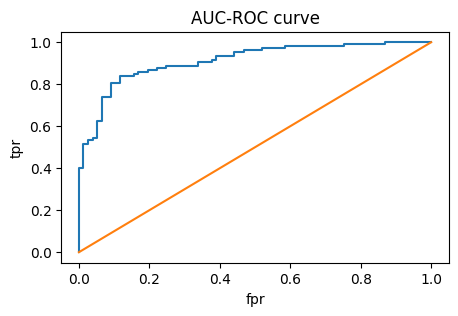

In [80]:
plt.figure(figsize=(5,3))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('AUC-ROC curve')
plt.show()

# KNN Classifier

In [81]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [82]:
confusion_matrix(y_test,y_pred)

array([[69,  8],
       [23, 84]])

In [83]:
accuracy_score(y_test,y_pred)

0.8315217391304348

In [84]:
precision_score(y_test,y_pred)

0.9130434782608695

In [85]:
recall_score(y_test,y_pred)

0.7850467289719626

In [86]:
f1_score(y_test,y_pred)

0.8442211055276382

# How to find K

In [87]:
error =[]
for k in range(2,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(x_sampled,y_sampled)
  y_pred=model.predict(x_test)
  error.append(np.mean(y_pred!=y_test))
print(error)

[np.float64(0.2608695652173913), np.float64(0.17391304347826086), np.float64(0.1956521739130435), np.float64(0.16847826086956522), np.float64(0.20652173913043478), np.float64(0.16304347826086957), np.float64(0.18478260869565216), np.float64(0.16847826086956522), np.float64(0.18478260869565216)]


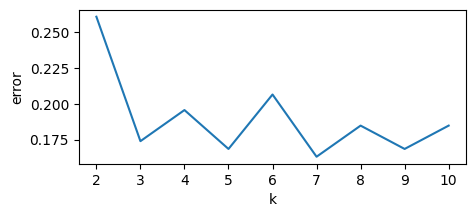

In [88]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

# **Health Insurance Prediction**

## **Problem Statement**

The goal of this project is to develop a **predictive model** that accurately estimates the **medical insurance costs** for individuals based on various **demographic, lifestyle, and health-related factors**. By applying **machine learning techniques**, we aim to assist **insurance companies** in better understanding their risk profiles and help **individuals gain insights** into how different factors influence their **insurance premiums**.

### **Import the libraries**

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load data**

In [91]:
data = pd.read_csv('/content/insurance.csv')

In [92]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Domain Analysis**
The descriptions of the variables based on the insurance dataset:

1. **Age**
   - **Description:** Age of the primary beneficiary covered by health insurance.
   - **Type:** Continuous numerical variable.

2. **Sex**
   - **Description:** Gender of the insurance contractor.
   - **Type:** Categorical variable with two levels: female, male.

3. **BMI (Body Mass Index)**
   - **Description:** Body mass index, which is a measure of body fat based on height and weight.
   - **Type:** Continuous numerical variable.
   - **Ideal Range:** Ideally between 18.5 to 24.9 kg/m².

4. **Children**
   - **Description:** Number of children covered by health insurance or number of dependents.
   - **Type:** Discrete numerical variable.

5. **Smoker**
   - **Description:** Binary indicator if the beneficiary is a smoker.
   - **Type:** Categorical variable with two levels: yes, no.

6. **Region**
   - **Description:** The beneficiary's residential area in the US.
   - **Type:** Categorical variable with four levels: northeast, southeast, southwest, northwest.

7. **Charges**
   - **Description:** Individual medical costs billed by health insurance.
   - **Type:** Continuous numerical variable.

### **Basic Checks**

In [93]:
# check number of rows and columns
data.shape

(1338, 7)

The dataset has 1338 rows and 7 columns.

In [94]:
# print first 5 rows
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [95]:
# print last 5 rows
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [96]:
# check info: memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [97]:
# print all columns
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [98]:
# print numerical columns
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [99]:
# print only categorical columns
cat_cols= data.select_dtypes(include='object')
cat_cols

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [100]:
# check data type of each column
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [101]:
# find statistical report for numerical data
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [102]:
# find statistical report for categorical data
data.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [103]:
# find unique values
for x in cat_cols:
  print(x,'-->',data[x].unique())

sex --> ['female' 'male']
smoker --> ['yes' 'no']
region --> ['southwest' 'southeast' 'northwest' 'northeast']


In [104]:
# find valueCount of each
for x in cat_cols:
  print(data[x].value_counts())
  print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



### **Data Cleaning**

**Check for missing values and handle them**

In [105]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**Check for duplicates and if any duplicate just drop**

In [106]:
data.duplicated().sum()

np.int64(1)

In [107]:
# drop duplicates
data.drop_duplicates(inplace=True)

In [108]:
data.duplicated().sum()

np.int64(0)

**Exploratory Data Analysis**

### **Univariate analysis**
Analysing single variable / column
- histogram
- count plot
- box plot

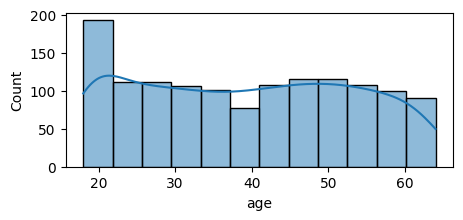

In [109]:
# check the distribution of age
plt.figure(figsize=(5,2))
sns.histplot(data,x='age',kde=True)
plt.show()

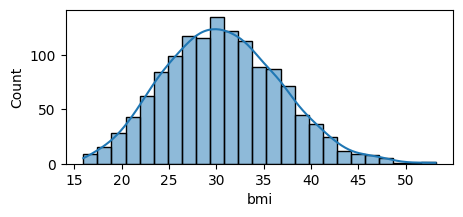

In [110]:
# check the distribution of bmi
plt.figure(figsize=(5,2))
sns.histplot(data,x='bmi',kde=True)
plt.show()

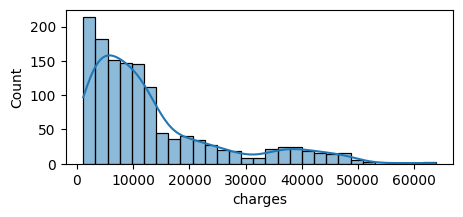

In [111]:
# check the distribution of charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

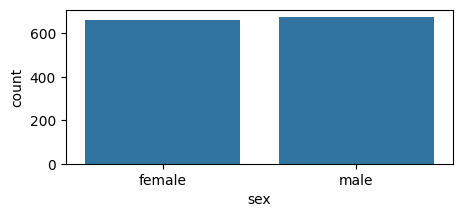

In [112]:
# Visualise count of male and female
plt.figure(figsize=(5,2))
sns.countplot(data,x='sex')
plt.show()

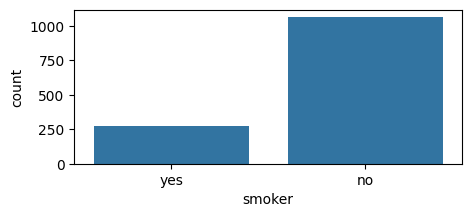

In [113]:
# Visualise count of smokers and non smoker
plt.figure(figsize=(5,2))
sns.countplot(data,x='smoker')
plt.show()

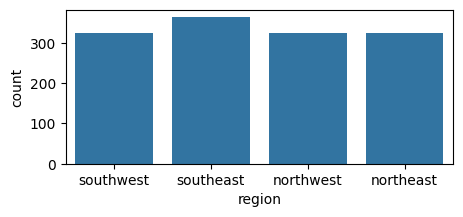

In [115]:
# Visualise count of region
plt.figure(figsize=(5,2))
sns.countplot(data,x='region')
plt.show()

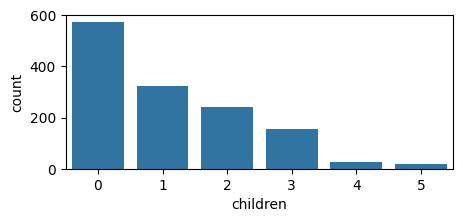

In [116]:
# Visualise count of children
plt.figure(figsize=(5,2))
sns.countplot(data,x='children')
plt.show()

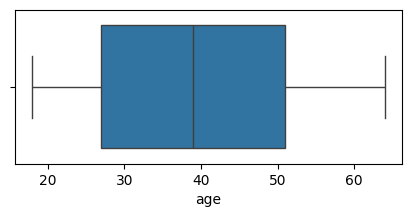

In [117]:
# check outliers in age
plt.figure(figsize=(5,2))
sns.boxplot(data,x='age')
plt.show()

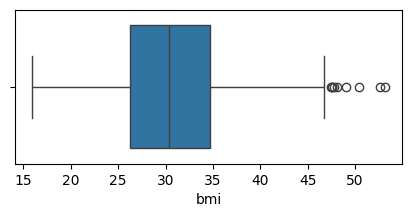

In [118]:
# check outliers in bmi
plt.figure(figsize=(5,2))
sns.boxplot(data,x='bmi')
plt.show()

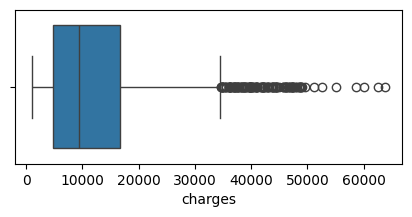

In [119]:
# check outliers in charges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='charges')
plt.show()

## **Bivariate Analysis**
Analysing two variables/columns
* Scatter
* line
* bar plot

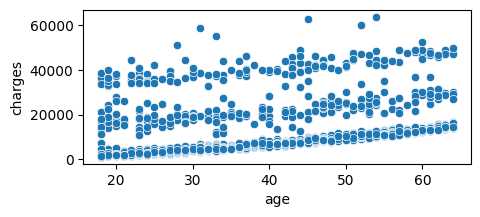

In [120]:
# check the relationship between age and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='age',y='charges')
plt.show()

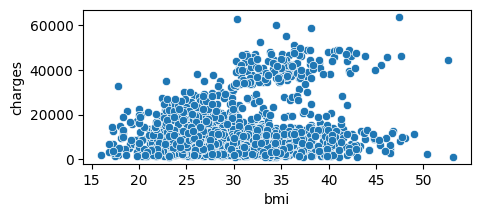

In [121]:
# check the relationship between bmi and charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='bmi',y='charges')
plt.show()

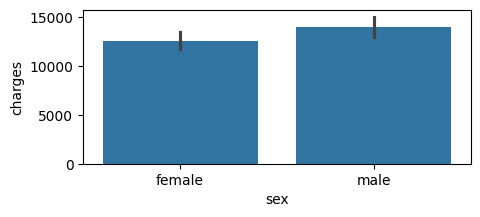

In [122]:
# Compare how charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='sex',y='charges')
plt.show()

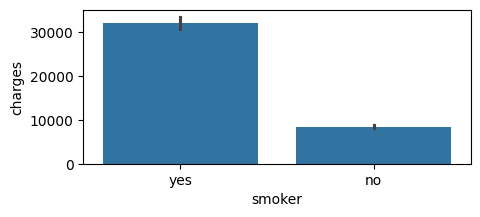

In [123]:
# compare how charges vary with smoker
plt.figure(figsize=(5,2))
sns.barplot(data,x='smoker',y='charges')
plt.show()

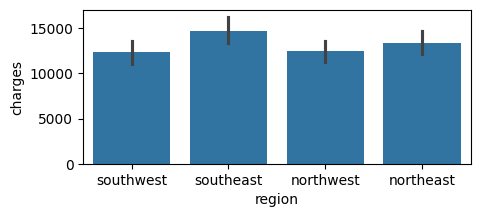

In [124]:
# compare how charges vary with region
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

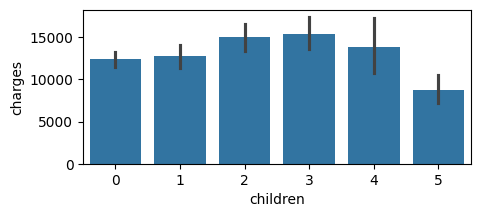

In [125]:
# compare how charges vary with children
plt.figure(figsize=(5,2))
sns.barplot(data,x='children',y='charges')
plt.show()

# **Multivariate Analysis**

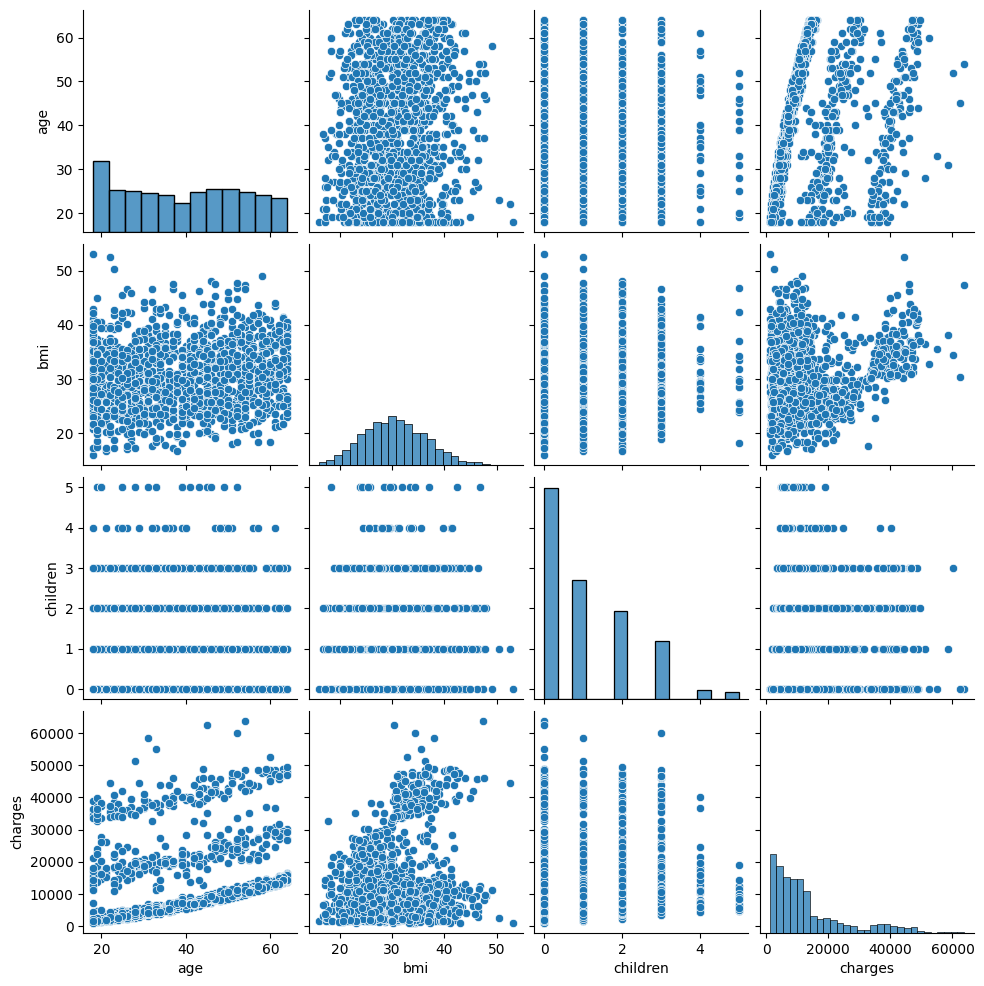

In [126]:
# pairplot: It creates scatter plot among all the numerical variables
sns.pairplot(data)

In [127]:
# heat map : Used to visualise the correlation
# Correlation measures how strong two variables

num_cols.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


<Axes: >

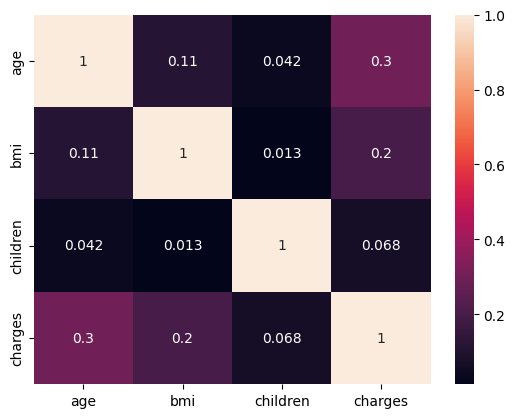

In [128]:
sns.heatmap(num_cols.corr(),annot=True)

## **Handle Outliers**

Outliers are extreme values which are far away from actual data or range.

Eg: Age of students : [20,21,22,23,24,98,100]

In this 98 and 100 are outliers.

**Ways to Identify Outliers**
- Box plot
- Sactter plot
- histogram

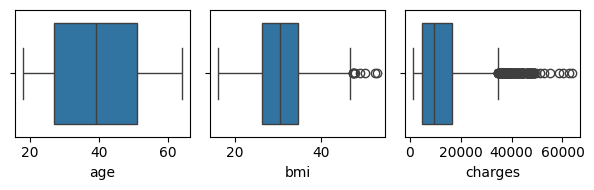

In [129]:
fig,ax = plt.subplots(1,3,figsize=(6,2))
sns.boxplot(data,x='age',ax=ax[0])
sns.boxplot(data,x='bmi',ax=ax[1])
sns.boxplot(data,x='charges',ax=ax[2])
plt.tight_layout()

There are outliers in bmi and charges towards right side.

**Find Outliers**
1. IQR(Inter quartile range): Used when data distribution is skewed.
2. 3-sigma rule : Used when data is normal
3. Outliers should handled only if % of outliers are less than 5%.

**Check the distibution of bmi and charges**

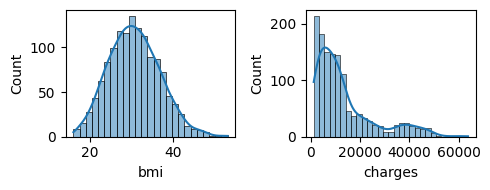

In [130]:
fig,ax=plt.subplots(1,2,figsize=(5,2))
sns.histplot(data,x='bmi',ax=ax[0],kde=True)
sns.histplot(data,x='charges',ax=ax[1],kde=True)
plt.tight_layout()

In [131]:
# find skew
data.loc[:,'bmi'].skew()

np.float64(0.28391419385321137)

In [132]:
data.loc[:,'charges'].skew()

np.float64(1.5153909108403483)

- BMI data distribution is normal.
- Charges distribution is right skewed.

**IQR method for Charges**

Data distribution is skewed

1. Find Q1
2. FInd Q3
3. IQR
4. lower_limit = Q1-1.5*IQR
5. upper_limit = Q3+ 1.5*IQR
6. If any value greater than upper limit or less than lower limit , we call them as outliers.

In [133]:
Q1 = data.loc[:,'charges'].quantile(0.25)
Q3 = data.loc[:,'charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [134]:
# filter all the values greater than upper_limit
data[data.loc[:,'charges']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [135]:
# filter values less than lower_limit
data[data.loc[:,'charges']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [136]:
# percentage of outliers
len(data[(data.loc[:,'charges']>upper_limit)|(data.loc[:,'charges']<lower_limit)
])/len(data)*100

10.396409872849663

Since % of outliers are 10% which are more than 5% that means all these high charges are important. If age is high obviously insurance charge will be high.

If it was less than 5% we could have replace with median.

**3 Sigma rule for Bmi**

Data distribution of bmi is normal

1. Find mean
2. Find Standard deviation
3. lower limit = mean - 3* std
4. upper limit = mean + 3* std
5. Any value greater than upper limit or less than lower limit is considered as outlier.

In [137]:
mean_val= data.loc[:,'bmi'].mean()
std_val =data.loc[:,'bmi'].std()
lower_limit = mean_val - 3*std_val
upper_limit = mean_val + 3*std_val

In [138]:
# filter values greater than upper limit
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.3254
847,23,male,50.38,1,no,southeast,2438.0552
1047,22,male,52.58,1,yes,southeast,44501.3982
1317,18,male,53.13,0,no,southeast,1163.4627


In [139]:
# filter values less than lower limit
data[data.loc[:,'bmi']<lower_limit]

,age,sex,bmi,children,smoker,region,charges


In [140]:
# find %
len(data[(data.loc[:,'bmi']>upper_limit)|(data.loc[:,'bmi']<lower_limit)])/len(data)*100

0.2991772625280479

since % of outliers is less than 5% we need to replace them with mean.

In [141]:
data.loc[data.loc[:,'bmi']>upper_limit,'bmi']= data.loc[:,'bmi'].mean()

In [142]:
data[data.loc[:,'bmi']>upper_limit]

,age,sex,bmi,children,smoker,region,charges


## **Encoding Techniques**

The process of converting text to numerical so that machine can can understand.

* Label Encoder
* One hot Encoder
* Ordinal Encoder
* Target Encoder
* Manual Encoder

# **Label Encoder**
Label Encoder assigns unique numbers to text starting from 0 according to alphabetical order.

In [144]:
# Yes - 1
# No -0

In [143]:
# red - 2
# green - 1
# blue -0

In [145]:
# UG -2
# PHD - 1
# PG - 0

# male - 1
# female - 0

# Label Encoder doesn't work when order matters or priority matters.
# Use label Encoder when order doesn't matter or no priority issues.

# One hot Encoding
Creates new columns according to categories and assign 1 if value exists else 0.

In [ ]:
# Gender | male | female
# male   | 1    | 0
# female | 0    | 1
# male   | 1    | 0
# female | 0    | 1
# male   | 1    | 0

# used one hot when all categories should be treated equally
# Avoid using when there are so many categories

In [146]:
# sex
data=pd.get_dummies(data,columns=['sex'],dtype='int')
data

,age,bmi,children,smoker,region,charges,sex_female,sex_male
0,19,27.900,0,yes,southwest,16884.92400,1,0
1,18,33.770,1,no,southeast,1725.55230,0,1
2,28,33.000,3,no,southeast,4449.46200,0,1
3,33,22.705,0,no,northwest,21984.47061,0,1
4,32,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,no,northwest,10600.54830,0,1
1334,18,31.920,0,no,northeast,2205.98080,1,0
1335,18,36.850,0,no,southeast,1629.83350,1,0
1336,21,25.800,0,no,southwest,2007.94500,1,0


# manual Encoder
Assign values manually based on priority

In [147]:
# UG - 0
# PG - 1
# PHD - 2

# Ordinal Encoder
Assign values based on order/ranking

In [148]:
# high : 2
# average:1
# low:0

# Target Encoding
Assign values based on comparing column with target column.

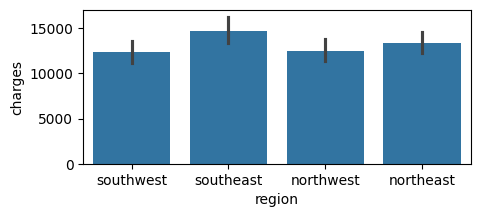

In [149]:
# region
plt.figure(figsize=(5,2))
sns.barplot(data,x='region',y='charges')
plt.show()

In [150]:
data.loc[:,'Region']=data.loc[:,'region'].map({'southwest':0,
                                               'northwest':1,'northeast':2,'southeast':3})

In [151]:
data.drop(columns='region',inplace=True)

#Scaling
If there is a huge variation among the values in different numerical column we using scaling to bring all the values to a same scale so that calculations becomes easy.

* Minmax scaler
* Standard scaler

#Minmax scaler
It transforms all the values into a range of 0 to 1

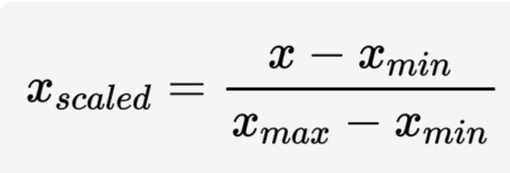

In [152]:
df = data.copy()

In [153]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['age']] = scaler.fit_transform(data[['age']])
data[['bmi']] = scaler.fit_transform(data[['bmi']])

# Standard Scaler
It transforms all the values to same scale so that mean of column of column will be 0 and std will be 1.

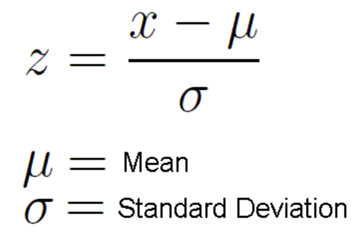

In [154]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age']]=scaler.fit_transform(df[['age']])
df[['bmi']]=scaler.fit_transform(df[['bmi']])


# Log Transformation
- Usually applied on target column only in regression.
- It is used to transform skewed data into normal distribution.
- Linear regression expects data distribution of target to be normal.

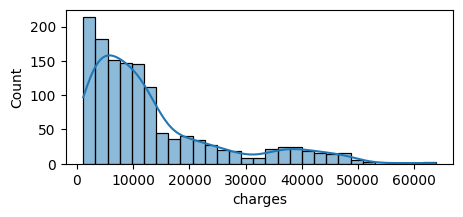

In [155]:
# charges
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

In [156]:
data.loc[:,'charges']= np.log(data.loc[:,'charges'])

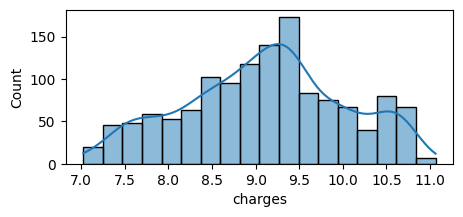

In [157]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='charges',kde=True)
plt.show()

# Feature Engineering
* Select best features
* drop the columns
* create a new column

# Split data for x and y

In [158]:
x = data.drop(columns='charges')
y= data['charges']

# Split data for training and testing

In [159]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [160]:
x_train.shape

(1069, 7)

In [161]:
x_test.shape

(268, 7)

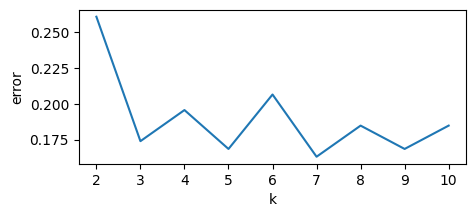

In [165]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()